PROJECT GOAL:
Create a model that can classify the type of flowers.

IMPORT LIBRARIES

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pathlib

LOAD DATASET

In [ ]:
import zipfile
import os
from google.colab import files

uploaded = files.upload()

zip_filename = list(uploaded.keys())[0]
extract_path = '/content/drive/MyDrive/Extracted images'

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Extracted to: {extract_path}")

# Explore extracted structure
for root, dirs, filenames in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in filenames[:3]:
            print(f"{indent}  {f}")

Saving flower-classes-5.zip to flower-classes-5.zip
Extracted to: /content/drive/MyDrive/Extracted images
Extracted images/
  dandelion/
    8011324555_375b7b5b0a.jpg
    19621170705_30bf8bf0ba.jpg
    9617087594_ec2a9b16f6.jpg
  daisy/
    7189043225_2fe781439a_n.jpg
    1392946544_115acbb2d9.jpg
    10466558316_a7198b87e2.jpg
  roses/
    5602220566_5cdde8fa6c_n.jpg
    466486216_ab13b55763.jpg
    3526860692_4c551191b1_m.jpg
  tulips/
    8838354855_c474fc66a3_m.jpg
    8838914676_8ef4db7f50_n.jpg
    8690791226_b1f015259f_n.jpg
  sunflowers/
    14928117202_139d2142cc_n.jpg
    14925398441_107f3e0304_n.jpg
    8481979626_98c9f88848_n.jpg
  flower_photos/
    .ipynb_checkpoints/
    tulips/
    roses/
    dandelion/
    daisy/
    sunflowers/


In [ ]:
# Adjust this path based on the folder structure printed in Cell 1
data_dir = pathlib.Path('/content/drive/MyDrive/Extracted images')

image_count = len(list(data_dir.glob('*/*.jpg'))) + len(list(data_dir.glob('*/*.png'))) + len(list(data_dir.glob('*/*.jpeg')))
print("Total images found:", image_count)

IMG_SIZE = 160
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

Total images found: 3670
Found 7340 files belonging to 6 classes.
Using 5872 files for training.
Found 7340 files belonging to 6 classes.
Using 1468 files for validation.
Classes: ['daisy', 'dandelion', 'flower_photos', 'roses', 'sunflowers', 'tulips']


SPLIT VALIDATION INTO VAL+TEST

In [ ]:
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

print('Validation batches:', tf.data.experimental.cardinality(val_ds).numpy())
print('Test batches:', tf.data.experimental.cardinality(test_ds).numpy())

Validation batches: 6
Test batches: 6


VISUALIZE SAMPLE IMAGES

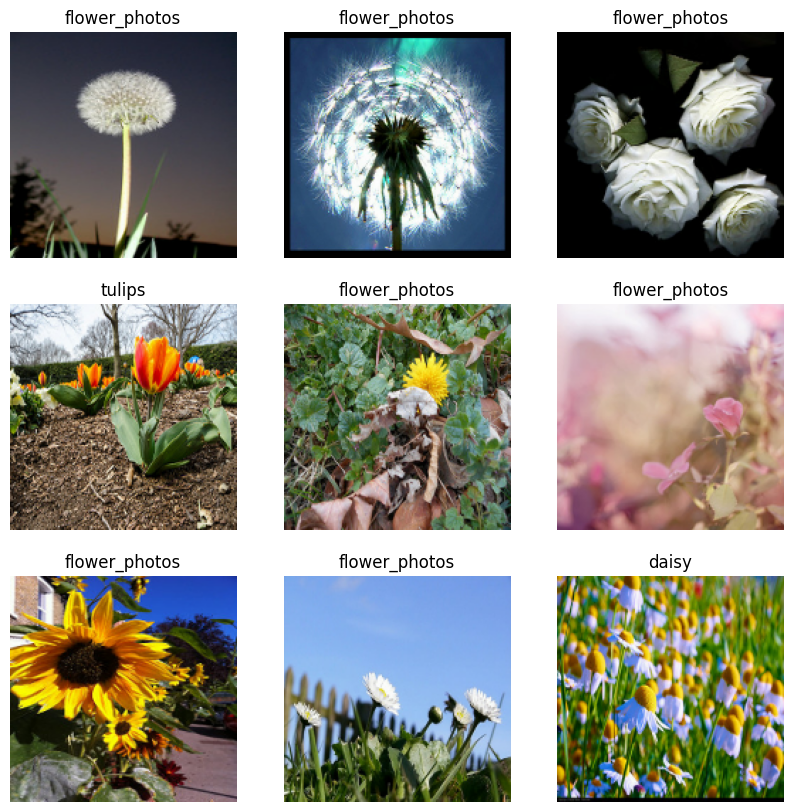

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

DATA PIPELINE AND PREPROCESS

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

BUILD THE MODEL(MOBILENETV2)

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

TRAIN THE MODEL

In [ ]:
EPOCHS = 15

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

Epoch 1/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 1137s 6s/step - accuracy: 0.4448 - loss: 1.3933 - val_accuracy: 0.4734 - val_loss: 1.1140
Epoch 2/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 165s 892ms/step - accuracy: 0.4717 - loss: 1.1403 - val_accuracy: 0.5053 - val_loss: 1.1020
Epoch 3/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 142s 772ms/step - accuracy: 0.4758 - loss: 1.0954 - val_accuracy: 0.4734 - val_loss: 1.0873
Epoch 4/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 144s 781ms/step - accuracy: 0.4813 - loss: 1.0637 - val_accuracy: 0.4521 - val_loss: 1.0911
Epoch 5/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 146s 792ms/step - accuracy: 0.4782 - loss: 1.0457 - val_accuracy: 0.4574 - val_loss: 1.0600
Epoch 6/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 149s 808ms/step - accuracy: 0.4808 - loss: 1.0265 - val_accuracy: 0.4681 - val_loss: 1.0990
Epoch 7/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 198s 785ms/step - accuracy: 0.4910 - loss: 1.0138 - val_accuracy: 0.4521 - val_loss: 1.0544
Epoch 8/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 147s 799ms/step - accuracy: 0.5031 - l

MODEL TRAINING PERFORMANCE

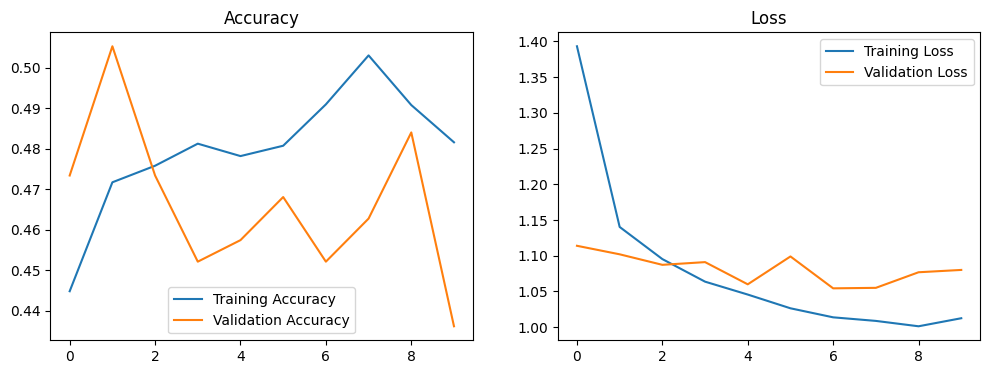

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()

EVALUATE ON TEST ACCURACY

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 596ms/step - accuracy: 0.4635 - loss: 1.0527
Test Accuracy: 0.4635


CLASSIFICATION REPORT AND CONFUSION MATRIX

               precision    recall  f1-score   support

        daisy       0.25      0.06      0.10        16
    dandelion       0.50      0.48      0.49        31
flower_photos       0.48      0.63      0.55        99
        roses       0.33      0.38      0.36        13
   sunflowers       0.00      0.00      0.00        11
       tulips       0.50      0.27      0.35        22

     accuracy                           0.46       192
    macro avg       0.34      0.30      0.31       192
 weighted avg       0.43      0.46      0.43       192



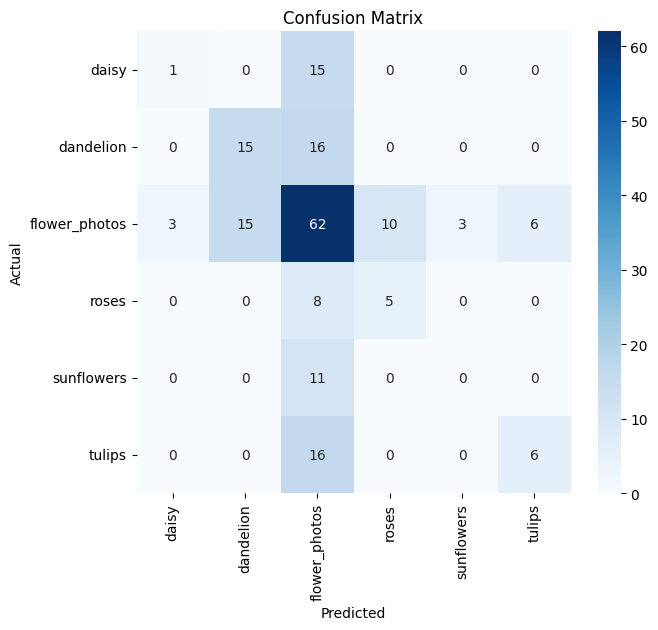

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

BUILD THE MODEL(EFFICIENTNETBO)

In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze base for phase 1

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
# EfficientNet expects raw pixel values (0-255); preprocessing is built into the model
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 5, 5, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,219,433 (16.10 MB)

 Trainable params: 167,302 (653.52 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

TRAIN THE MODEL

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6
)

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - accuracy: 0.4201 - loss: 1.5461 - val_accuracy: 0.5000 - val_loss: 0.9762 - learning_rate: 0.0010
Epoch 2/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 247s 1s/step - accuracy: 0.4629 - loss: 1.1576 - val_accuracy: 0.4362 - val_loss: 0.9680 - learning_rate: 0.0010
Epoch 3/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - accuracy: 0.4816 - loss: 1.0463 - val_accuracy: 0.4681 - val_loss: 0.9697 - learning_rate: 0.0010
Epoch 4/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - accuracy: 0.4871 - loss: 0.9711 - val_accuracy: 0.4043 - val_loss: 0.9614 - learning_rate: 0.0010
Epoch 5/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 240s 1s/step - accuracy: 0.4947 - loss: 0.9463 - val_accuracy: 0.3989 - val_loss: 0.9192 - learning_rate: 0.0010
Epoch 6/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - accuracy: 0.5010 - loss: 0.9222 - val_accuracy: 0.4149 - val_loss: 0.9043 - learning_rate: 0.0010
Epoch 7/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.5005 - loss: 0.

FINE TUNE TOP LAYERS OF EFFICIENTNET

In [ ]:
# Unfreeze the base model
base_model.trainable = True

# Freeze all layers except the last 30 (fine-tune only the top)
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile with a much lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 5, 5, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,219,433 (16.10 MB)

 Trainable params: 1,663,462 (6.35 MB)

 Non-trainable params: 2,555,971 (9.75 MB)

FINE-TUNING(TRAIN THE MODEL)

In [ ]:
fine_tune_epochs = 10
total_epochs = len(history_phase1.epoch) + fine_tune_epochs

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history_phase1.epoch[-1] + 1,
    callbacks=[early_stop, reduce_lr]
)

Epoch 11/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 304s 2s/step - accuracy: 0.5082 - loss: 1.0010 - val_accuracy: 0.4574 - val_loss: 0.9168 - learning_rate: 1.0000e-05
Epoch 12/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.4939 - loss: 0.9891 - val_accuracy: 0.4628 - val_loss: 0.9147 - learning_rate: 1.0000e-05
Epoch 13/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 282s 2s/step - accuracy: 0.5027 - loss: 0.9772 - val_accuracy: 0.4628 - val_loss: 0.9149 - learning_rate: 5.0000e-06
Epoch 14/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 310s 2s/step - accuracy: 0.5128 - loss: 0.9558 - val_accuracy: 0.4681 - val_loss: 0.9126 - learning_rate: 5.0000e-06


MODEL TRAINING PERFORMANCE

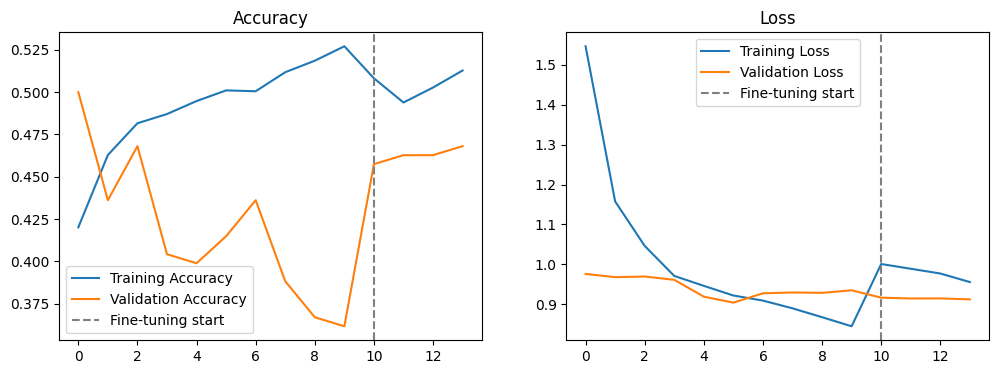

In [ ]:
acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(len(history_phase1.history['accuracy']), color='gray', linestyle='--', label='Fine-tuning start')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(len(history_phase1.history['loss']), color='gray', linestyle='--', label='Fine-tuning start')
plt.legend()
plt.title('Loss')
plt.show()

EVALUATE ON TEST ACCURACY

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Final Test Accuracy: {test_acc:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.3958 - loss: 1.0014
Final Test Accuracy: 0.3958


CLASSIFICATION REPORT AND CONFUSION MATRIX

               precision    recall  f1-score   support

        daisy       0.29      0.25      0.27        16
    dandelion       0.54      0.42      0.47        31
flower_photos       0.42      0.46      0.44        99
        roses       0.35      0.54      0.42        13
   sunflowers       0.13      0.18      0.15        11
       tulips       0.40      0.18      0.25        22

     accuracy                           0.40       192
    macro avg       0.36      0.34      0.33       192
 weighted avg       0.41      0.40      0.39       192



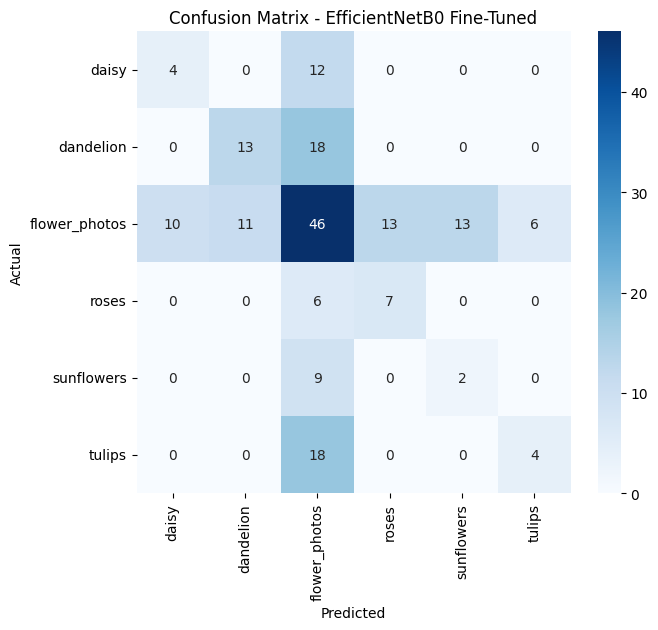

In [ ]:
y_true, y_pred = [], []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - EfficientNetB0 Fine-Tuned')
plt.show()

CONCLUSION:-This project successfully developed and evaluated a deep learning model for flower image classification using transfer learning techniques. Pre-trained convolutional neural network architectures, including MobileNetV2 and EfficientNetB0, were implemented to classify flower images into five different classes. Data preprocessing, augmentation, model training, fine-tuning, and performance evaluation were carried out to improve the model's classification capability.
